# 03 — Environmental Niche Analysis of SNIPE-Bearing Genomes

**Requires**: BERDL REST API for AlphaEarth query; remainder runs locally.

This notebook compares AlphaEarth environmental embeddings between species
that carry SNIPE homologues and those that do not, testing whether SNIPE-bearing
bacteria occupy distinct environmental niches.

**Caveat**: AlphaEarth covers only ~28.4% of genomes (biased toward
environmental isolates with lat/lon data).

In [1]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy import stats
from pathlib import Path

DATA_DIR = Path("../data")
FIG_DIR = Path("../figures")

API_URL = "https://hub.berdl.kbase.us/apis/mcp/delta/tables/query"
TOKEN = os.environ.get("KBASE_AUTH_TOKEN") or os.environ.get("KBASE_TOKEN")
HEADERS = {"Authorization": f"Bearer {TOKEN}", "Content-Type": "application/json"}

def query_berdl(sql, limit=1000, offset=0, retries=3, backoff=10):
    """Execute a SQL query against the BERDL REST API with retry."""
    payload = {"query": sql, "limit": limit, "offset": offset}
    for attempt in range(retries):
        try:
            resp = requests.post(API_URL, headers=HEADERS, json=payload, timeout=120)
            resp.raise_for_status()
            data = resp.json()
            return pd.DataFrame(data["result"]), data.get("pagination", {})
        except requests.exceptions.HTTPError as e:
            if resp.status_code in (408, 502, 503, 504) and attempt < retries - 1:
                wait = backoff * (attempt + 1)
                print(f"    retry {attempt+1}/{retries} after {resp.status_code}, waiting {wait}s...")
                time.sleep(wait)
            else:
                raise

def query_all(sql, limit=1000):
    """Paginate through a query using API-level offset."""
    frames = []
    offset = 0
    while True:
        df, pag = query_berdl(sql, limit=limit, offset=offset)
        frames.append(df)
        total = pag.get("total_count", len(df))
        has_more = pag.get("has_more", False)
        print(f"  ... {offset + len(df)}/{total} rows")
        if not has_more or len(df) < limit:
            break
        offset += limit
    result = pd.concat(frames, ignore_index=True)
    print(f"Total rows: {len(result)}")
    return result

def q(sql, limit=1000):
    """Convenience wrapper returning just the DataFrame."""
    df, _ = query_berdl(sql, limit=limit)
    return df

plt.rcParams['figure.dpi'] = 150

In [2]:
# Load SNIPE species list from notebook 01
df_snipe = pd.read_csv(DATA_DIR / "snipe_both_domains.csv")
snipe_species = set(df_snipe['gtdb_species_clade_id'].unique())
print(f"SNIPE-bearing species: {len(snipe_species)}")

SNIPE-bearing species: 1697


## Step 1: Get AlphaEarth embeddings for SNIPE vs non-SNIPE species

We use server-side aggregation to compute mean embeddings per species,
then compare SNIPE-bearing vs non-SNIPE species.

In [3]:
# Get species-level mean AlphaEarth embeddings
# AlphaEarth has 64 dimensions (A00-A63)
embed_cols = ', '.join([f'AVG(ae.A{i:02d}) AS A{i:02d}' for i in range(64)])

embed_sql = f"""
SELECT g.gtdb_species_clade_id,
       COUNT(*) AS n_genomes,
       {embed_cols}
FROM kbase_ke_pangenome.alphaearth_embeddings_all_years ae
JOIN kbase_ke_pangenome.genome g
  ON g.genome_id = ae.genome_id
GROUP BY g.gtdb_species_clade_id
ORDER BY g.gtdb_species_clade_id
"""

df_embed = query_all(embed_sql)
print(f"Species with AlphaEarth data: {len(df_embed)}")

# Convert numeric columns
for col in [f'A{i:02d}' for i in range(64)] + ['n_genomes']:
    df_embed[col] = pd.to_numeric(df_embed[col], errors='coerce')

# Label SNIPE status
df_embed['has_snipe'] = df_embed['gtdb_species_clade_id'].isin(snipe_species)
print(f"SNIPE species with embeddings: {df_embed['has_snipe'].sum()}")
print(f"Non-SNIPE species with embeddings: {(~df_embed['has_snipe']).sum()}")

  ... 1000/15046 rows


  ... 2000/15046 rows


  ... 3000/15046 rows


  ... 4000/15046 rows


  ... 5000/15046 rows


...

  ... 12000/15046 rows


  ... 13000/15046 rows


  ... 14000/15046 rows


  ... 15000/15046 rows


  ... 15046/15046 rows
Total rows: 15046
Species with AlphaEarth data: 15046
SNIPE species with embeddings: 1069
Non-SNIPE species with embeddings: 13977


## Step 2: PCA of Environmental Embeddings

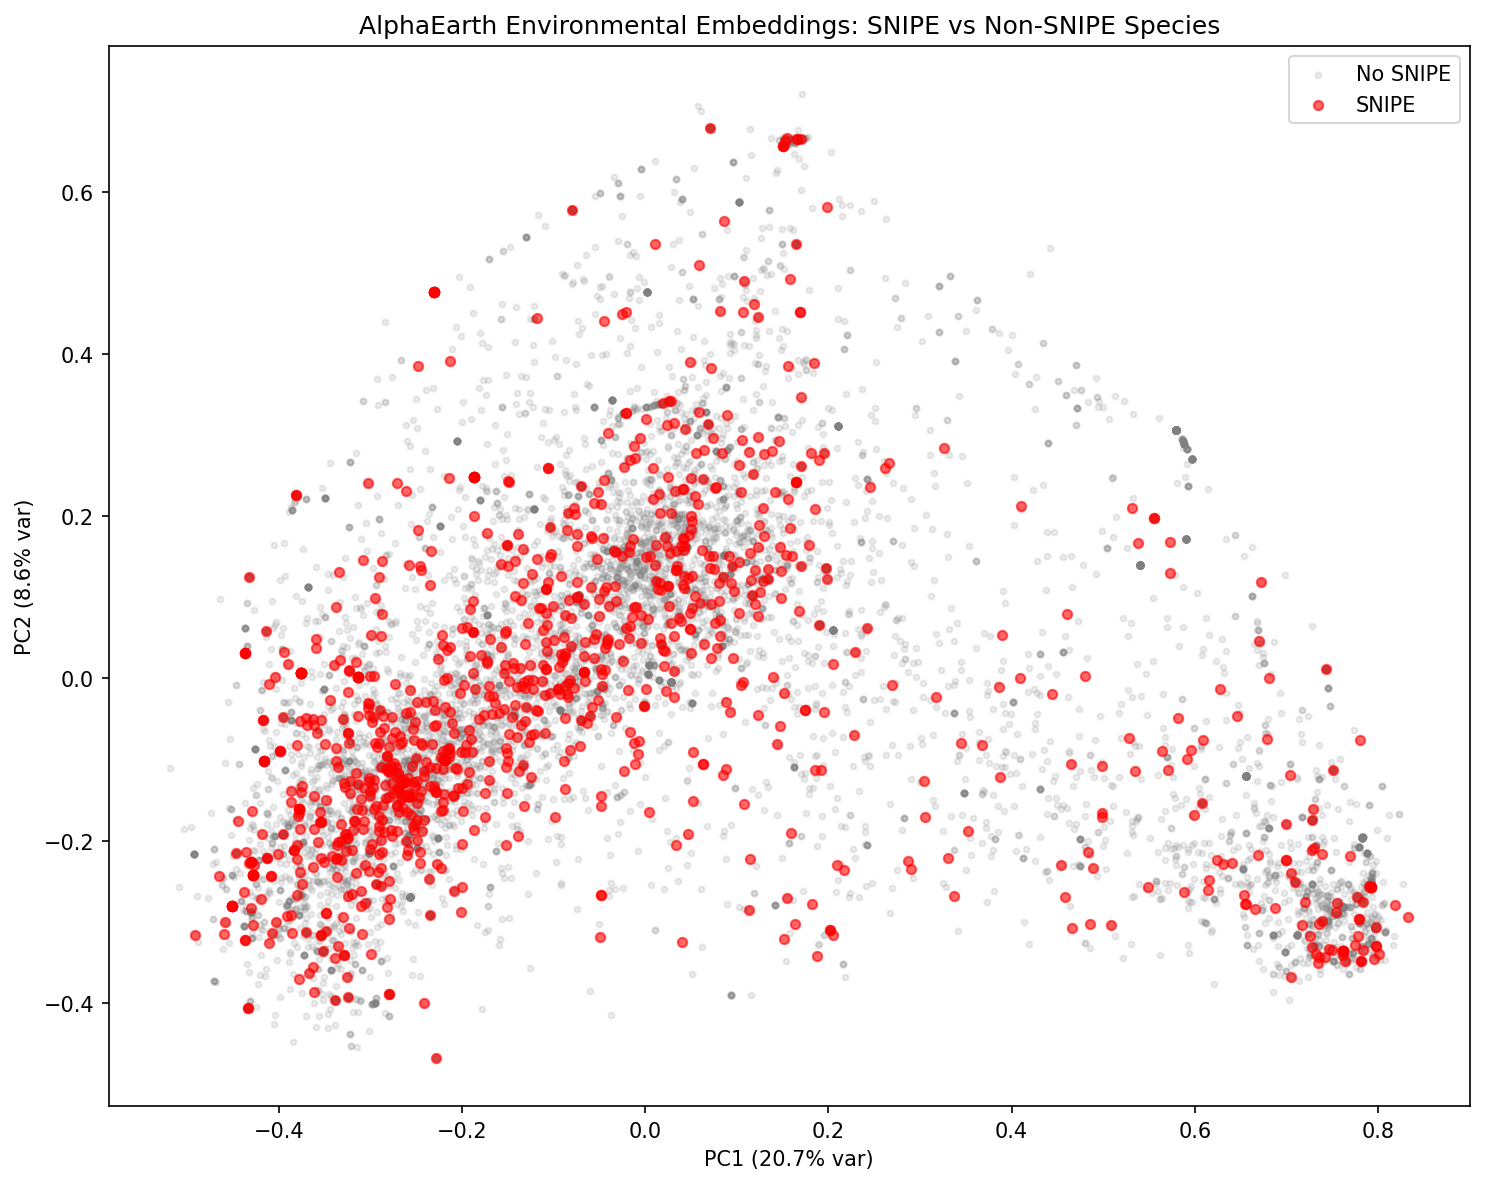

In [4]:
from sklearn.decomposition import PCA

embed_matrix = df_embed[[f'A{i:02d}' for i in range(64)]].values

# Handle any NaN rows
valid_mask = ~np.isnan(embed_matrix).any(axis=1)
embed_clean = embed_matrix[valid_mask]
labels_clean = df_embed.loc[valid_mask, 'has_snipe'].values

pca = PCA(n_components=2)
pcs = pca.fit_transform(embed_clean)

fig, ax = plt.subplots(figsize=(10, 8))
# Plot non-SNIPE first (background)
ax.scatter(pcs[~labels_clean, 0], pcs[~labels_clean, 1],
           alpha=0.15, s=8, c='grey', label='No SNIPE')
# Plot SNIPE on top
ax.scatter(pcs[labels_clean, 0], pcs[labels_clean, 1],
           alpha=0.6, s=20, c='red', label='SNIPE')
ax.set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)')
ax.set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)')
ax.set_title('AlphaEarth Environmental Embeddings: SNIPE vs Non-SNIPE Species')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "snipe_alphaearth_pca.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 3: Statistical Comparison of Embedding Dimensions

In [5]:
# Compare each AlphaEarth dimension between SNIPE and non-SNIPE species
results = []
for dim in range(64):
    col = f'A{dim:02d}'
    snipe_vals = df_embed.loc[df_embed['has_snipe'], col].dropna()
    other_vals = df_embed.loc[~df_embed['has_snipe'], col].dropna()
    
    if len(snipe_vals) > 1 and len(other_vals) > 1:
        t_stat, p_val = stats.ttest_ind(snipe_vals, other_vals)
        # Cohen's d
        pooled_std = np.sqrt(
            ((len(snipe_vals)-1)*snipe_vals.std()**2 + (len(other_vals)-1)*other_vals.std()**2)
            / (len(snipe_vals) + len(other_vals) - 2)
        )
        cohens_d = (snipe_vals.mean() - other_vals.mean()) / pooled_std if pooled_std > 0 else 0
        results.append({
            'dimension': col,
            'snipe_mean': snipe_vals.mean(),
            'other_mean': other_vals.mean(),
            't_stat': t_stat,
            'p_value': p_val,
            'cohens_d': cohens_d
        })

df_stats = pd.DataFrame(results)

# Bonferroni correction
df_stats['p_adjusted'] = df_stats['p_value'] * 64
df_stats['significant'] = df_stats['p_adjusted'] < 0.05

print(f"Significant dimensions (Bonferroni p < 0.05): {df_stats['significant'].sum()}/64")
sig = df_stats[df_stats['significant']].sort_values('p_adjusted')
if len(sig) > 0:
    print(sig[['dimension', 'snipe_mean', 'other_mean', 'cohens_d', 'p_adjusted']].to_string())
else:
    print("No significant differences detected.")

Significant dimensions (Bonferroni p < 0.05): 22/64
   dimension  snipe_mean  other_mean  cohens_d    p_adjusted
19       A19    0.044848    0.020779  0.261596  4.956580e-14
45       A45    0.078512    0.101855 -0.224092  3.212180e-10
63       A63    0.017590    0.046458 -0.221383  5.757765e-10
51       A51    0.072952    0.053993  0.204658  1.819471e-08
56       A56    0.024969    0.005364  0.200491  4.132154e-08
24       A24   -0.034447   -0.052626  0.194057  1.420769e-07
62       A62   -0.065395   -0.045629 -0.187056  5.215785e-07
55       A55   -0.107193   -0.086057 -0.182874  1.110129e-06
37       A37   -0.028952   -0.013352 -0.180275  1.760945e-06
50       A50   -0.015169    0.005762 -0.176790  3.236743e-06
36       A36   -0.096179   -0.071402 -0.176278  3.536507e-06
18       A18   -0.016833    0.001028 -0.168254  1.372027e-05
34       A34    0.031747    0.012991  0.166306  1.889888e-05
17       A17    0.075632    0.058836  0.144102  5.690469e-04
6        A06    0.003762   -0.011

## Step 4: Save Results

In [6]:
df_stats.to_csv(DATA_DIR / "snipe_alphaearth_stats.csv", index=False)
df_embed[['gtdb_species_clade_id', 'has_snipe', 'n_genomes']].to_csv(
    DATA_DIR / "snipe_species_embed_labels.csv", index=False
)

print("Saved:")
print(f"  snipe_alphaearth_stats.csv         — {len(df_stats)} dimensions")
print(f"  snipe_species_embed_labels.csv     — {len(df_embed)} species")

Saved:
  snipe_alphaearth_stats.csv         — 64 dimensions
  snipe_species_embed_labels.csv     — 15046 species
